# Phase 7 — Evaluation + Write-up

1. Intrinsic evaluation on locked test set (precision, recall, F1, ROC-AUC, confusion matrices)
2. Extrinsic validation against external benchmarks
3. Carbon footprint summary

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import spacy
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize

In [2]:
ROOT       = Path('..').resolve()
RAW_DIR    = ROOT / 'data' / 'raw'
RESULTS    = ROOT / 'results'
FEAT_DIR   = RAW_DIR / 'features'
CARBON_DIR = RESULTS / 'carbon'

# Load train and TEST sets
with open(RAW_DIR / 'labeled' / 'labeled_passages.jsonl') as f:
    train_set = [json.loads(l) for l in f]
with open(RAW_DIR / 'labeled' / 'test_set.jsonl') as f:
    test_set = [json.loads(l) for l in f]
with open(RAW_DIR / 'labeled' / 'ambiguous_passages.jsonl') as f:
    ambiguous = [json.loads(l) for l in f]

train_texts  = [p['text'] for p in train_set]
train_labels = [p['label'] for p in train_set]
test_texts   = [p['text'] for p in test_set]
test_labels  = [p['label'] for p in test_set]

X_train = np.load(FEAT_DIR / 'labeled_embeddings.npy')

# Re-encode test set embeddings
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
X_test = normalize(embedder.encode(test_texts, batch_size=64, convert_to_numpy=True), norm='l2')

# Lemmatize for TF-IDF (must match preprocessing in 04_modeling)
try:
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

def lemmatize(text: str) -> str:
    doc = nlp(text.lower())
    return ' '.join(t.lemma_ for t in doc if not t.is_stop and not t.is_punct and t.is_alpha)

lemmatized_train = [lemmatize(t) for t in train_texts]
lemmatized_test  = [lemmatize(t) for t in test_texts]

print(f"Train: {len(train_labels)}  |  Test: {len(test_labels)}  |  Ambiguous (excluded): {len(ambiguous)}")
print(f"Ambiguous proportion: {len(ambiguous) / (len(train_labels) + len(test_labels) + len(ambiguous)):.1%}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train: 52  |  Test: 20  |  Ambiguous (excluded): 30
Ambiguous proportion: 29.4%


## Section 1 — Intrinsic evaluation on locked test set

In [3]:
def evaluate(name: str, y_true, y_pred, y_prob) -> dict:
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    return {'model': name, 'precision': round(p,3), 'recall': round(r,3),
            'f1': round(f1,3), 'roc_auc': round(auc,3)}


# ── kNN ────────────────────────────────────────────────────────────────────────
try:
    best_k = int(open(RESULTS / 'best_k.txt').read().strip())
except FileNotFoundError:
    best_k = 5
    print(f"best_k.txt not found — using k={best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute')
knn.fit(X_train, train_labels)
knn_pred  = knn.predict(X_test)
knn_prob  = knn.predict_proba(X_test)[:, 1]

# ── TF-IDF + LR (with lemmatization, matching 04_modeling) ────────────────────
tfidf_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])
tfidf_pipe.fit(lemmatized_train, train_labels)
tfidf_pred = tfidf_pipe.predict(lemmatized_test)
tfidf_prob = tfidf_pipe.predict_proba(lemmatized_test)[:, 1]

results = [
    evaluate('kNN (k={})'.format(best_k), test_labels, knn_pred, knn_prob),
    evaluate('TF-IDF + LR',               test_labels, tfidf_pred, tfidf_prob),
]
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv(RESULTS / 'evaluation_metrics.csv', index=False)

with open(RESULTS / 'best_k.txt', 'w') as f:
    f.write(str(best_k))

      model  precision  recall  f1  roc_auc
  kNN (k=3)        0.5   0.333 0.4    0.755
TF-IDF + LR        0.0   0.000 0.0    0.863


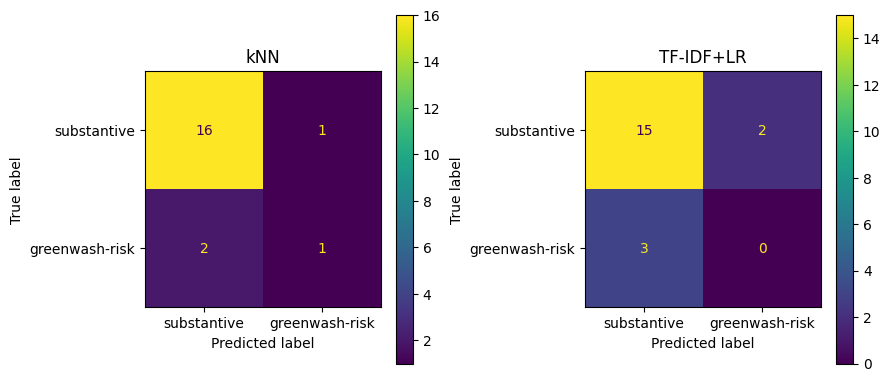

In [4]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, y_pred) in zip(axes, [('kNN', knn_pred), ('TF-IDF+LR', tfidf_pred)]):
    cm = confusion_matrix(test_labels, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['substantive', 'greenwash-risk']).plot(ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Section 2 — Extrinsic validation

Compare brand risk scores to known external benchmarks as a plausibility check.  
**N=6 — treat as descriptive, not hypothesis-testing.**

In [5]:
brand_scores = pd.read_csv(RESULTS / 'brand_risk_scores.csv')

# External benchmarks — manually curated from public sources
# Good On You ratings: 1 (We Avoid) → 5 (Great)
# Regulatory: 1 = confirmed action, 0 = no action
external = pd.DataFrame([
    {'brand': 'H&M',       'good_on_you': 2, 'regulatory_action': 1,
     'regulatory_note': 'ASA ruling 2022 (misleading green claims in advertising)'},
    {'brand': 'Zara',      'good_on_you': 2, 'regulatory_action': 0,
     'regulatory_note': 'EU regulatory scrutiny; no ruling as of 2025'},
    {'brand': 'Patagonia', 'good_on_you': 4, 'regulatory_action': 0,
     'regulatory_note': 'B Corp certified; no regulatory action'},
    {'brand': "L'Oreal",   'good_on_you': None, 'regulatory_action': 1,
     'regulatory_note': 'EU complaint 2022 (misleading sustainability claims)'},
    {'brand': 'Sephora',   'good_on_you': None, 'regulatory_action': 1,
     'regulatory_note': 'Class action lawsuit (California, 2022)'},
    {'brand': 'Lush',      'good_on_you': None, 'regulatory_action': 0,
     'regulatory_note': 'Certified cruelty-free; B Corp pending'},
])

validation = brand_scores.merge(external, on='brand')
print(validation[['brand', 'mean_knn_prob', 'good_on_you', 'regulatory_action', 'regulatory_note']].to_string(index=False))

print("\n[Note: We treat extrinsic validation as a plausibility check, not a formal hypothesis test, given N=6.]")

    brand  mean_knn_prob  good_on_you  regulatory_action                                          regulatory_note
  L'Oreal         0.3684          NaN                  1     EU complaint 2022 (misleading sustainability claims)
  Sephora         0.3017          NaN                  1                  Class action lawsuit (California, 2022)
     Zara         0.0978          2.0                  0             EU regulatory scrutiny; no ruling as of 2025
      H&M         0.0950          2.0                  1 ASA ruling 2022 (misleading green claims in advertising)
Patagonia         0.0599          4.0                  0                   B Corp certified; no regulatory action
     Lush         0.0333          NaN                  0                   Certified cruelty-free; B Corp pending

[Note: We treat extrinsic validation as a plausibility check, not a formal hypothesis test, given N=6.]


## Section 3 — Carbon footprint summary

In [6]:
import platform, os

emissions_path = CARBON_DIR / 'emissions.csv'
if emissions_path.exists():
    em = pd.read_csv(emissions_path)
    print("Per-run emissions log:")
    print(em[['project_name', 'timestamp', 'duration', 'emissions', 'energy_consumed']].to_string(index=False))

    total_kwh  = em['energy_consumed'].sum()
    total_co2e = em['emissions'].sum()
    print(f"\nTotal energy consumed: {total_kwh:.4f} kWh")
    print(f"Total CO2e:            {total_co2e:.4f} kg")

    hardware = platform.node()
    summary = f"""# Carbon Footprint Summary — green-claims-nlp

## Hardware
- Platform: {platform.system()} {platform.release()}
- CPU: {platform.processor() or 'unknown'}
- GPU: None (CPU inference throughout)

## Per-component breakdown

{em[['timestamp', 'duration', 'emissions', 'energy_consumed']].to_markdown(index=False)}

## Totals
- Total energy: {total_kwh:.4f} kWh
- Total CO2e:   {total_co2e:.4f} kg

## Reporting note
We report the carbon cost of this pipeline as a matter of research transparency,
consistent with emerging norms in climate-adjacent NLP research (Courty et al., 2023).

## Citation
Courty, B., Schmidt, V., Goyal-Kamal, et al. (2023). CodeCarbon: Estimate and Track
Carbon Emissions from Machine Learning Computing. https://github.com/mlco2/codecarbon
"""
    summary_path = CARBON_DIR / 'carbon_summary.md'
    with open(summary_path, 'w') as f:
        f.write(summary)
    print(f"\nSaved → {summary_path}")
else:
    print(f"emissions.csv not found at {emissions_path} — run 01_preprocessing and 03_features and 04_modeling first.")

Per-run emissions log:
    project_name           timestamp   duration    emissions  energy_consumed
green-claims-nlp 2026-04-02T21:06:02 231.183934 1.122694e-04     5.137378e-04
green-claims-nlp 2026-04-02T23:42:13  26.354039 1.279669e-05     5.855686e-05
green-claims-nlp 2026-04-02T23:47:07   0.017436 7.879940e-09     3.605811e-08
green-claims-nlp 2026-04-02T23:47:59  51.692945 2.510350e-05     1.148721e-04
green-claims-nlp 2026-04-03T00:04:08   0.014030 6.402533e-09     2.929759e-08
green-claims-nlp 2026-04-03T00:05:00  52.702049 2.559358e-05     1.171146e-04
green-claims-nlp 2026-04-03T00:07:35 207.857210 1.009417e-04     4.619028e-04

Total energy consumed: 0.0013 kWh
Total CO2e:            0.0003 kg

Saved → /Users/mandy.sun/green-claims-nlp/results/carbon/carbon_summary.md
